In [7]:
import numpy as np
import matplotlib.pyplot as plt

In [8]:
# Define the Schrödinger equation based on the given potential (atomic units)
# Stationary Schrödinger equation: -(hbar^2/2m) psi'' + V psi = E psi
# In atomic units hbar = m = 1, so -1/2 psi'' + V psi = E psi
# Rearranged: psi'' = 2(V - E) psi
# V = V0*x/x0 for 0 < x < x0
# V = V0 elsewhere
# x0 = 5, V0 = 50
# Split into two first-order equations: u' = v, v' = 2(V - E)u
x0, V0 = 5, 50

# RK4 function
# E: trial energy
# xa, xb: start and end point of the integration
# u, v: psi and psi' at the start point
# n: number of steps
# Returns the x points, psi at every point, and psi' at the end point
def rk4(E, xa, xb, u, v, n=1000):
    h = (xb - xa)/n  # step size, negative if we go from right to left
    x = np.linspace(xa, xb, n+1)
    us = [u]  # save psi at every step
    g = lambda x, u, v: (v, 2*(V0*x/x0 - E)*u)  # right-hand side: u' = v, v' = 2(V - E)u
    for xi in x[:-1]:
        # RK4 steps, same as in T2A1
        k1u, k1v = g(xi, u, v)
        k2u, k2v = g(xi + h/2, u + h/2*k1u, v + h/2*k1v)
        k3u, k3v = g(xi + h/2, u + h/2*k2u, v + h/2*k2v)
        k4u, k4v = g(xi + h, u + h*k3u, v + h*k3v)
        u += h/6*(k1u + 2*k2u + 2*k3u + k4u)
        v += h/6*(k1v + 2*k2v + 2*k3v + k4v)
        us.append(u)
    return x, np.array(us), v

- Outside the well V = V0, so psi is an exponential there.
- Same as section 4.9 in, I integrate from both sides and match them at the turning point (V = E)
- If I only integrate from left to right, the solution blows up where psi should decay.

In [9]:
# Left side: psi = e^(kx) outside the well so psi = 1, psi' = k at x = 0
# Right side: psi = e^(-kx) outside the well so psi = 1, psi' = -k at x = x0
# k = sqrt(2(V0 - E))
# Turning point: xt = x0*E/V0
def shoot(E):
    k = np.sqrt(2*(V0 - E))
    xt = x0*E/V0
    xl, ul, vl = rk4(E, 0, xt, 1, k)
    xr, ur, vr = rk4(E, x0, xt, 1, -k)
    return xl, ul, vl, xr, ur, vr

# Both sides match at xt when ul'/ul = ur'/ur
# f = ul'*ur - ur'*ul so we don't divide by zero
def f(E):
    xl, ul, vl, xr, ur, vr = shoot(E)
    return vl*ur[-1] - vr*ul[-1]

# Finding the eigenvalues

- f(E) changes sign at an eigenvalue
- First I scan E in steps of 0.5 to find where the sign changes, then use bisection on that interval

In [10]:
# Bisection: keep the half where the sign changes until the interval is smaller than tol
def bisection(a, b, tol=1e-10):
    while b - a > tol:
        m = (a + b)/2
        if f(a)*f(m) < 0: b = m
        else: a = m
    return (a + b)/2

# Scan E from 0.5 to V0, stop after the 2 lowest eigenvalues
eigen = []
Es = np.arange(0.5, V0, 0.5)
for i in range(len(Es) - 1):
    if f(Es[i])*f(Es[i+1]) < 0:
        eigen.append(bisection(Es[i], Es[i+1]))
    if len(eigen) == 2: break
print(eigen)

[np.float64(7.588273770787055), np.float64(14.00829759662156)]


The two lowest eigenvalues are E0 = 7.588 a.u. and E1 = 14.008 a.u.

# Plotting the eigenfunctions

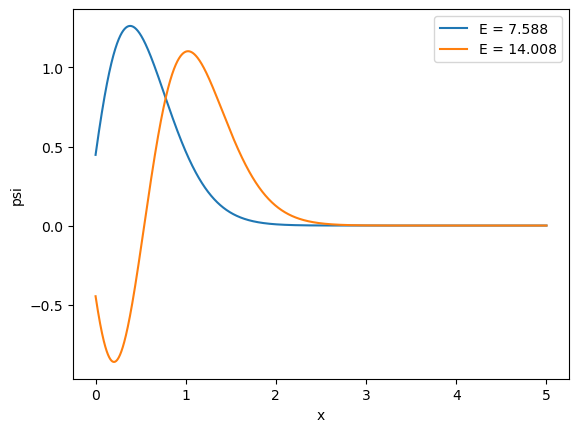

In [11]:
# Scale the left part so both parts meet at xt, then join and normalize
for E in eigen:
    xl, ul, vl, xr, ur, vr = shoot(E)
    ul = ul*ur[-1]/ul[-1]
    x = np.concatenate([xl, xr[::-1]])
    psi = np.concatenate([ul, ur[::-1]])
    psi = psi/np.sqrt(np.trapezoid(psi**2, x))
    plt.plot(x, psi, label=f"E = {E:.3f}")
plt.xlabel("x"); plt.ylabel("psi"); plt.legend()
plt.show()

The ground state has no node and the first excited state has one node. Both are near the left wall, where the potential is lowest.

# Conclusion
The two lowest eigenvalues are E0 = 7.588 a.u. and E1 = 14.008 a.u.